In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

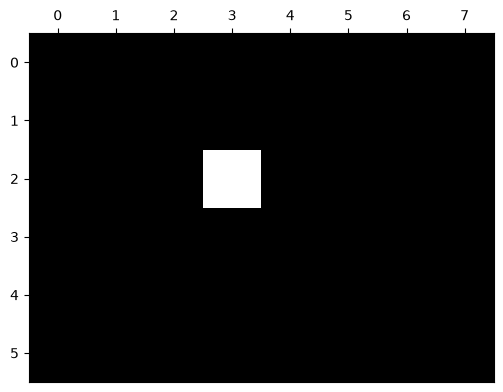

In [2]:
#Generating grayscale image
im = np.zeros((6,8), dtype = np.uint8)
im[2,3] = 255
fig, ax = plt.subplots(1, 1, figsize = (6,8))
ax.imshow(im, cmap= 'gray', vmin=0, vmax=255)
ax.xaxis.set_ticks_position('top')
plt.show()

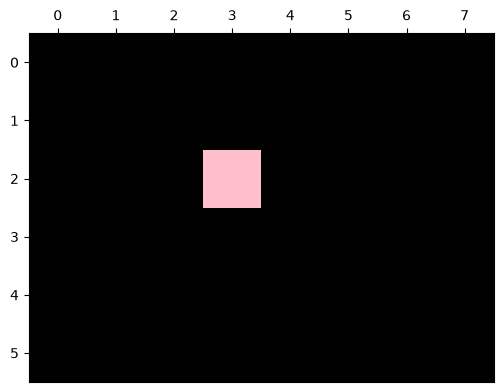

In [3]:
#Creating the colour image
im = np.zeros((6, 8, 3), dtype = np.uint8)
im[2,3] = [255, 190, 203]
fig, ax = plt.subplots(1, 1, figsize = (6, 8))
ax.imshow(im)
ax.xaxis.set_ticks_position('top')
plt.show()

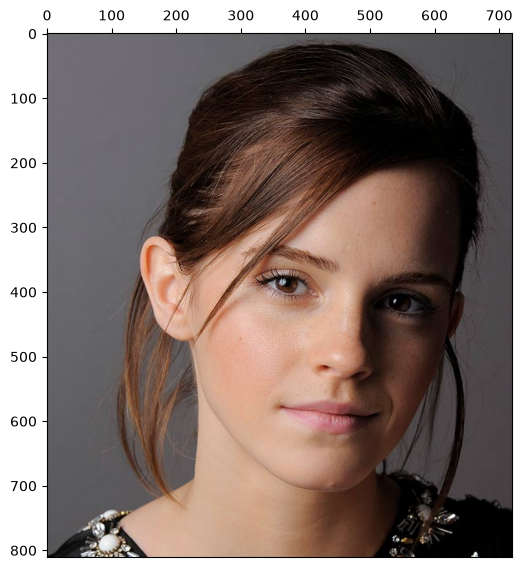

In [4]:
im = cv.imread('images/emma.jpg')
assert im is not None
fig, ax = plt.subplots(1, 1, figsize = (6,8))
ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax.xaxis.set_ticks_position('top')
plt.show()


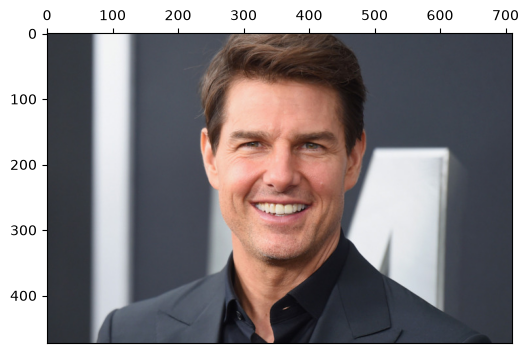

Image Shape:  (473, 710, 3)
Image Data Type:  uint8
Image Size:  1007490


In [5]:
im = cv.imread('images/tom.jpg')
fig, ax = plt.subplots(1, 1, figsize = (6,8))
ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax.xaxis.set_ticks_position('top')
plt.show()
print('Image Shape: ', im.shape)
print('Image Data Type: ', im.dtype)
print('Image Size: ', im.size)


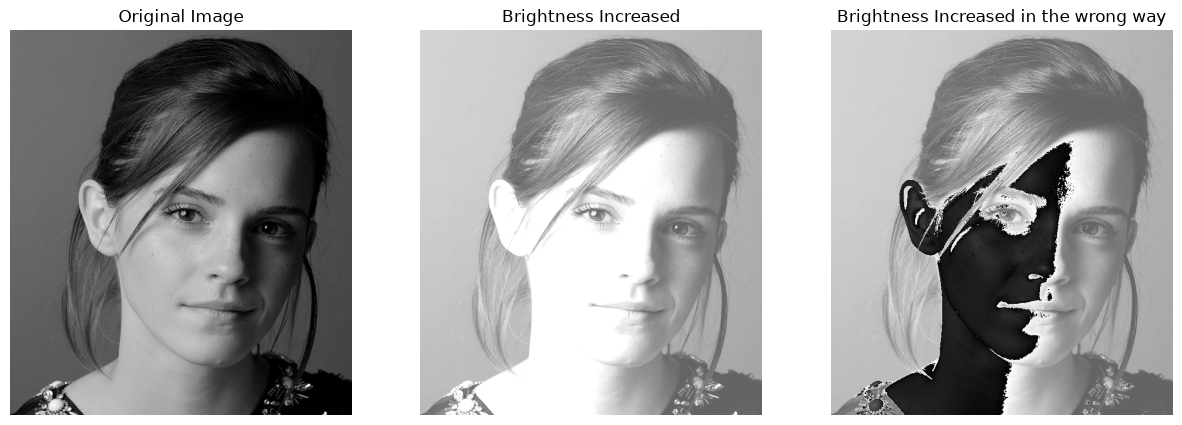

In [15]:
#Increasing the brightness
im1 = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Increasing the brightness right way
im2 = cv.add(im1, 100)

#Increasing the brightness wrong way
im3 = im1 + 100

fig, ax = plt.subplots(1, 3, figsize= (15, 30))
ax[0].imshow(im1, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[1].imshow(im2, cmap ='gray', vmin = 0, vmax = 255)
ax[1].set_title('Brightness Increased')
ax[2].imshow(im3, cmap = 'gray', vmin = 0, vmax = 255)
ax[2].set_title('Brightness Increased in the wrong way')
for a in ax:
    a.axis('off')
plt.show()

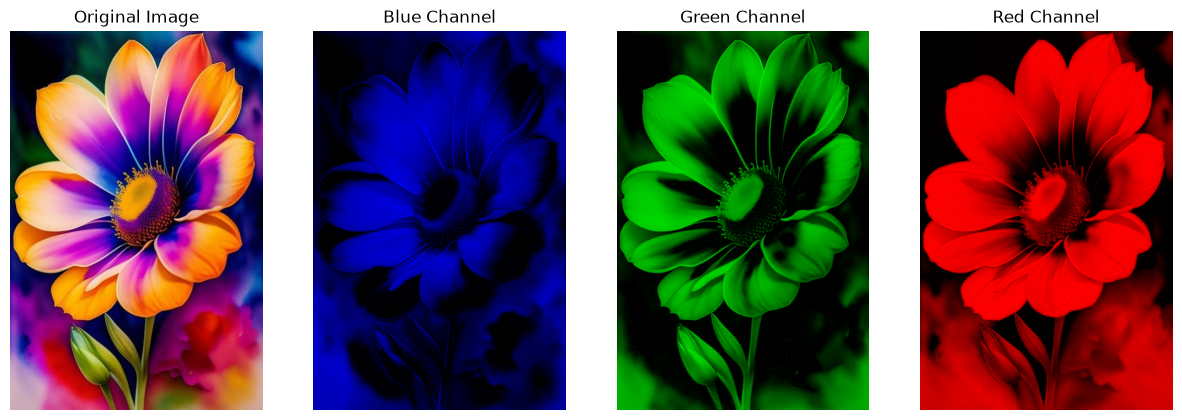

In [22]:
#Obtaining one colour plane

im = cv.imread('images/rgb_flowers.jpg')

#Blue channel
im_blue = im.copy()
im_blue[:,:,1], im_blue[:,:,2] = 0, 0

#Green channel
im_green = im.copy()
im_green[:,:,0], im_green[:,:,2] = 0, 0

#Red channel
im_red = im.copy()
im_red[:,:,0], im_red[:,:,1] = 0, 0


fig, ax = plt.subplots(1, 4, figsize = (15, 30))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(im_blue, cv.COLOR_BGR2RGB))
ax[1].set_title('Blue Channel')
ax[2].imshow(cv.cvtColor(im_green, cv.COLOR_BGR2RGB))
ax[2].set_title('Green Channel')
ax[3].imshow(cv.cvtColor(im_red, cv.COLOR_BGR2RGB))
ax[3].set_title('Red Channel')

for a in ax:
    a.axis('off')

plt.show()



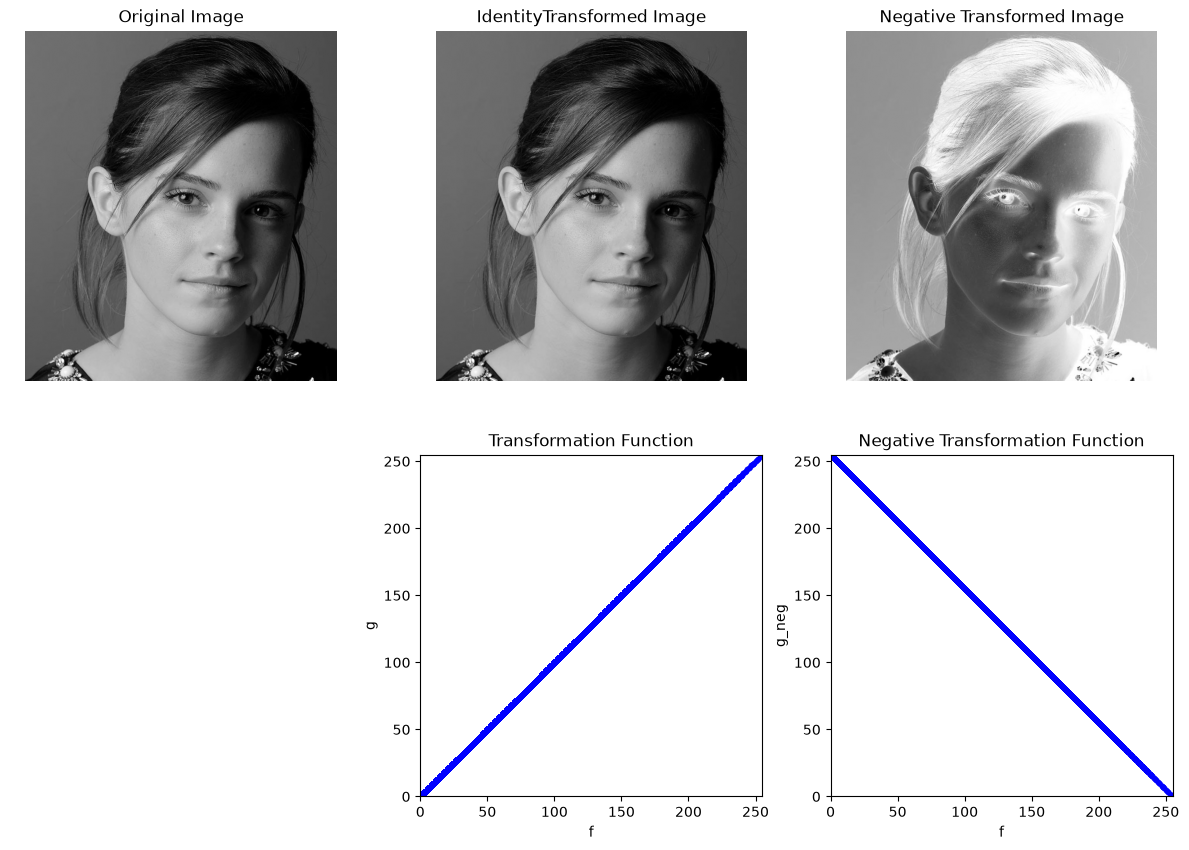

In [36]:
#Intensity transformations
f = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert f is not None

#Identity transformation
t = np.arange(256, dtype = np.uint8)
g = t[f]

#Negative transformation
t_neg = 255 - t
g_neg = t_neg[f]

fig, ax = plt.subplots(2, 3, figsize= (15, 10))
ax[0, 0].imshow(f, cmap = 'gray', vmin = 0, vmax = 255)
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(g, cmap ='gray', vmin = 0, vmax = 255)
ax[0, 1].set_title('IdentityTransformed Image')
ax[0, 1].axis('off')

x = f.ravel()
y = g.ravel()
ax[1, 1].plot(x, y, '.', color='blue', alpha=0.2)
ax[1, 1].set_xlim(0, 255)
ax[1, 1].set_ylim(0, 255)
ax[1, 1].set_xlabel('f')
ax[1, 1].set_ylabel('g')
ax[1, 1].set_title('Transformation Function')
ax[1, 1].set_aspect('equal')

ax[0, 2].imshow(g_neg, cmap ='gray', vmin = 0, vmax = 255)
ax[0, 2].set_title('Negative Transformed Image')
ax[0, 2].axis('off')

x_neg = f.ravel()
y_neg = g_neg.ravel()
ax[1, 2].plot(x_neg, y_neg, '.', color='blue', alpha=0.2)
ax[1, 2].set_xlim(0, 255)  
ax[1, 2].set_ylim(0, 255)
ax[1, 2].set_xlabel('f')
ax[1, 2].set_ylabel('g_neg')
ax[1, 2].set_title('Negative Transformation Function')
ax[1, 2].set_aspect('equal')

ax[1, 0].axis('off')
ax[1, 0].set_aspect('equal')



plt.show()




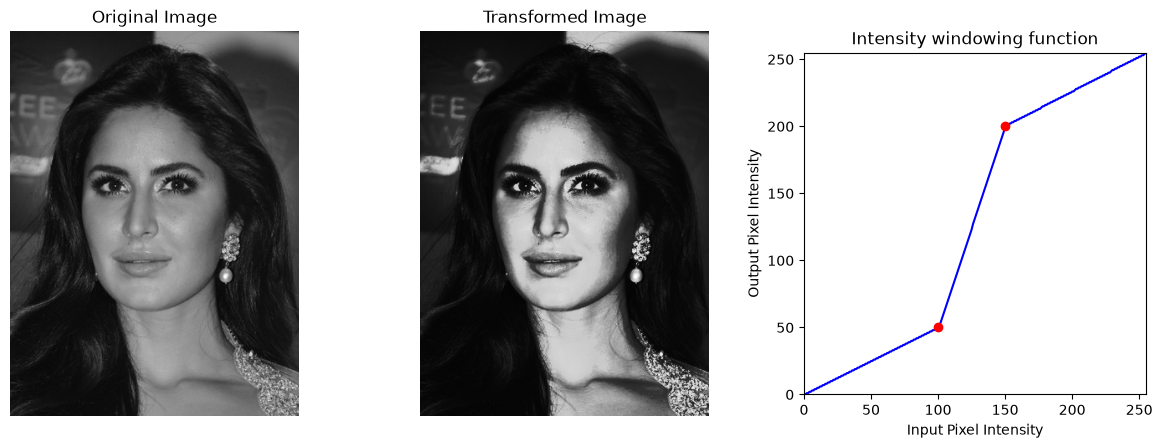

In [3]:
#Windowing points
c = np.array([(100,50), (150, 200)])

#Defining segments
t1 = np.linspace(0, c[0, 1], c[0, 0] + 1 - 0).astype('uint8')
t2 = np.linspace(c[0, 1] + 1, c[1, 1], c[1, 0] - c[0, 0]).astype('uint8')
t3 = np.linspace(c[1, 1] + 1, 255, 255 - c[1, 0]).astype('uint8')

#Comnbining into one
transform = np.concatenate((t1, t2, t3)).astype(np.uint8)
assert transform.shape[0] == 256

img_orig = cv.imread('images/Katrina.jpg', cv.IMREAD_GRAYSCALE)
assert img_orig is not None

image_transformed = cv.LUT(img_orig, transform)

fig, ax = plt.subplots(1, 3, figsize=(15, 5)) 

ax[0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')

ax[1].imshow(image_transformed, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed Image')

x = np.arange(256) 
y = transform      
ax[2].plot(x, y, color='blue') 
ax[2].plot(c[:,0], c[:,1], 'ro') 
ax[2].set_xlim(0, 255)  
ax[2].set_ylim(0, 255)
ax[2].set_xlabel('Input Pixel Intensity')
ax[2].set_ylabel('Output Pixel Intensity')
ax[2].set_title('Intensity windowing function')
ax[2].set_aspect('equal')

ax[0].axis('off')
ax[1].axis('off')

plt.show()

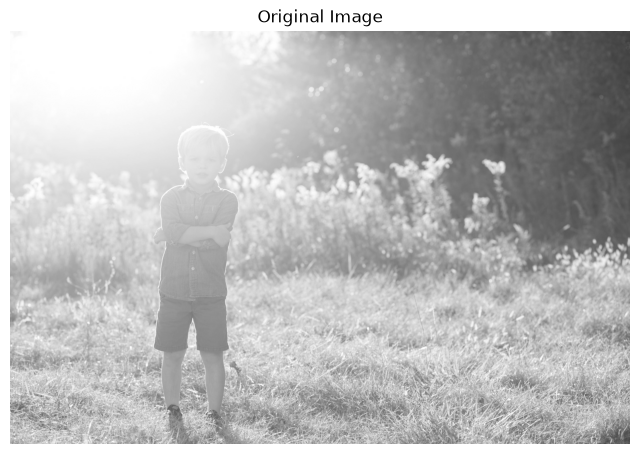

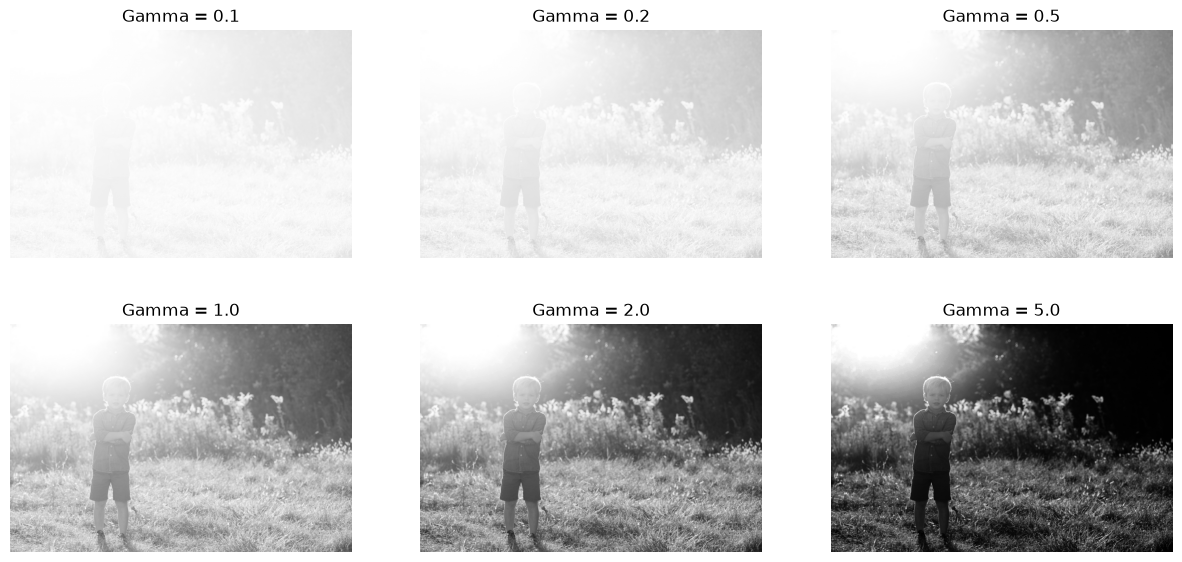

In [9]:
#Gamma correction
gamma_values = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

im_orig = cv.imread('images/Little_boy.jpg', cv.IMREAD_GRAYSCALE)
assert im_orig is not None

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.imshow(im_orig, cmap = 'gray', vmin = 0, vmax = 255)
ax.set_title('Original Image')
ax.axis('off')

fig2, ax2 = plt.subplots(2, 3, figsize=(15, 7))

#gamma launching
for i, gamma in enumerate(gamma_values):
    #Gamma function
    t_gamma = np.array([round(((i / 255.0) ** gamma) * 255) for i in range(256)], dtype=np.uint8)

    #Tranformations
    im_gamma = cv.LUT(im_orig, t_gamma)
    
    ax2[i // 3, i % 3].imshow(im_gamma, cmap = 'gray', vmin = 0, vmax = 255)
    ax2[i // 3, i % 3].set_title(f'Gamma = {gamma}')
    ax2[i // 3, i % 3].axis('off')

plt.show()


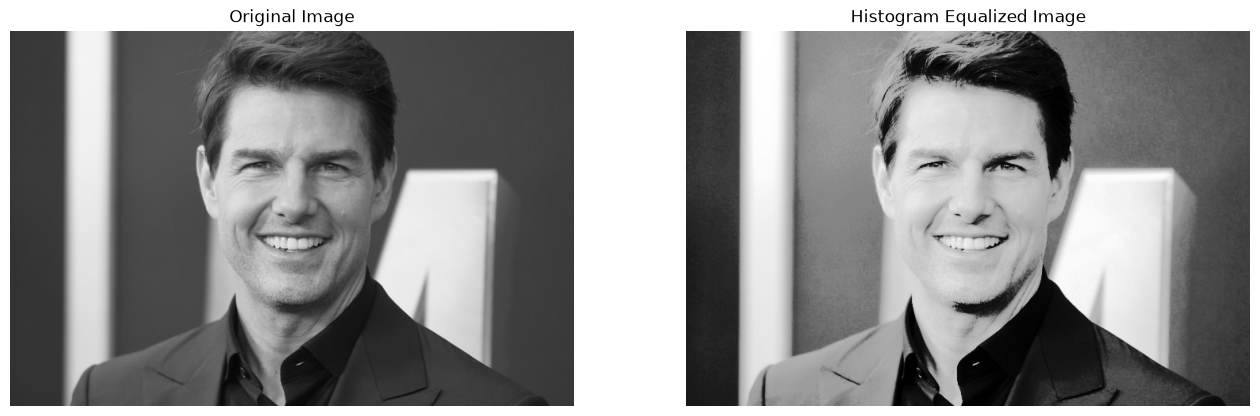

In [11]:
#Histogram equalization
im_new = cv.imread('images/tom.jpg', cv.IMREAD_GRAYSCALE)
assert im_new is not None

im_eq = cv.equalizeHist(im_new)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(im_new, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(im_eq, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Histogram Equalized Image')   
ax[1].axis('off')

plt.show()